In [1]:
import numpy as np
import torch
import torch_geometric as tg
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from torch_geometric import seed_everything

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper', font_scale=2)

In [ ]:
def load_result(file, inductive=False):
    df = pd.read_csv(f'./results/{file}')
    if inductive:
        # rename 'test_cost' as 'cost'
        df = df.rename(columns={'test_cost': 'cost'})
    # rename "GNN" as "NodeGNN"
    df['method'] = df['method'].replace({'GNN': 'NodeGNN', 'kwikcluster': 'KwikCluster', 'modified_pivot': 'ModifiedPivot',})
    # rename AmazonComputers as AmazonPC
    df['name'] = df['name'].replace({'AmazonComputers': 'AmazonPC', 'FacebookPagePage': 'Facebook'})
    return df



def custom_agg_func(precision, ty):
    # define an aggregation function that returns mean and sem as string with precision decimal places and type (f or e)
    def agg_func(x):
        # return a string with mean and sem
        mean = x.mean()
        sem = x.sem()
        if sem < 10**(-precision):
            return f"{mean:.{precision}{ty}} ± {sem:.0e}"
        return f"{mean:.{precision}{ty}} ± {sem:.{precision}{ty}}"
    return agg_func

def aggregate_df(dataset_df, variables=['cost', 'found_clusters']):
    
    agg_datasets = []
    for var in variables:
        if var == 'NMI':
            agg_func = custom_agg_func(3, 'f')
        elif var == 'runtime':
            agg_func = custom_agg_func(2, 'e')
        else:
            agg_func = custom_agg_func(3, 'f')
        if var == 'cost':
            # first normalize cost by dividing by min cost per dataset
            dataset_df[var] = dataset_df.groupby('name')[var].transform(lambda x: x / x.min())
        # if var=='inference_time', substitute NaN with the 'runtime' column
        if var == 'inference_time':
            dataset_df[var] = dataset_df[var].fillna(dataset_df['runtime'])

        agg_df = dataset_df.groupby(['name', 'method'])[var].agg(agg_func).reset_index()
        agg_df = agg_df.rename(columns={var: 'value'})
        agg_df['metric'] = var
        agg_datasets.append(agg_df)
    agg_df = pd.concat(agg_datasets, ignore_index=True)
    # sort by name and metric
    agg_df['metric'] = pd.Categorical(agg_df['metric'], categories=variables, ordered=True)
    agg_df = agg_df.sort_values(['name', 'metric'])

    # create a new dataframe, with multindex as dataset name and metric, methods as columns
    agg_df = agg_df.pivot(index=['name', 'metric'], columns='method', values='value').reset_index()
    # create multindex columns to avoid repetition on 'name'
    agg_df.set_index(['name', 'metric'], inplace=True)

    return agg_df


def clean_df(full_df, datasets, inductive=False):
    dataset_df = full_df[full_df['name'].isin(datasets)]
    
    dataset_df = dataset_df[~dataset_df['method'].isin(['EMBOnly',])]
    print(dataset_df['method'].unique())
    dataset_df = dataset_df[~dataset_df['objective'].isin([ 'MinClustering', 'MinIntraDisagree'])]
    
    if inductive:
        dataset_df['method'].replace({'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)', 'LinearLink': 'LinkLinear (I)'}, inplace=True)
        method_order = ['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)']
    else:
        # order datasets according to methods  'NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP'
        method_order = ['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP']
    dataset_df['method'] = pd.Categorical(dataset_df['method'], categories=method_order, ordered=True)
    dataset_df = dataset_df.sort_values('method')
    print(dataset_df['method'].unique())
    # do the same for dataset names according to cc_bench_datasets order
    dataset_df['name'] = pd.Categorical(dataset_df['name'], categories=datasets, ordered=True)
    dataset_df = dataset_df.sort_values('name')
    return dataset_df


def plot_cost_results(full_df, title, datasets, ylims=(0.9, 2.1), figsize=(12,6), logscale=False, s=10, inductive=False):

    dataset_df = clean_df(full_df, datasets, inductive=inductive)

    # for each name normalize the cost by dividing by the minimum cost achieved on that dataset by any method
    dataset_df['cost'] = dataset_df.groupby('name')['cost'].transform(lambda x: x / x.min())

    plt.figure(figsize=figsize)
    sns.pointplot(data=dataset_df, x='name', y='cost', hue='method', palette='Set2', linestyle='', dodge=0.5, markers=['o', 's', 'D', 'X', 'P', 'h'], markersize=s, linewidth=s/3, errorbar='se')
    
    plt.xlabel('')
    plt.ylabel('MD cost (normalized by min)')
    if logscale:
        plt.yscale('log')
    plt.ylim(*ylims)
    #plt.yscale('log')
    plt.legend(title='Method')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'./results/figures/costs_across_{title}.pdf')
    plt.show()
    return
    



def plot_cost_results_inductive(full_df, title, datasets, ylims=[(0.9, 2.1), (7, 1100)], figsize=(12,6), logscale=False, s=10):
    
    dataset_df = clean_df(full_df, datasets, inductive=True)
    dataset_df['run'] = dataset_df.index % 5  # assuming 5 runs per method per dataset
    print(dataset_df.head())

    # for each name normalize the cost by dividing by the minimum cost achieved on that dataset by any method
    

    dataset_df['cost'] = dataset_df.groupby(['name', 'run'])['cost'].transform(lambda x: x / x.min())
    #dataset_df['cost'] = dataset_df.groupby('name')['cost'].transform(lambda x: x / x.min())

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=figsize)
    fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

    set2_colors = sns.color_palette("Set2")
    set2_first = set2_colors[0]

    # higher plot: NodeGNN
    sns.pointplot(data=dataset_df[dataset_df['method']=='NodeGNN (I)'], x='name', y='cost', linestyle='', marker='o', color=set2_first, markersize=s, linewidth=s/3, errorbar='se', ax=ax1)

    # lower plot: other methods
    sns.pointplot(data=dataset_df[dataset_df['method']!='NodeGNN (I)'], x='name', y='cost', hue='method', palette='Set2', linestyle='', dodge=0.5, markers=['s', 'D', 'X', 'P'], markersize=s, linewidth=s/3, errorbar='se', ax=ax2)

    ax2.set_ylim(*ylims[0])
    ax2.set_xlabel('')
    ax1.set_ylabel('')
    ax2.set_ylabel('')

    fig.supylabel('MD cost (normalized by min)')

    ax2.legend_.remove()
    fig.legend(title='Method', loc='center left', bbox_to_anchor=(0.1, 0.5))
    # 
    ax1.grid(True)
    ax2.grid(True)

    # hide the spines between ax and ax2
    
    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax1.set_ylim(*ylims[1])
    ax2.xaxis.tick_bottom()
    if logscale:
        ax1.set_yscale('log')

    # Now, let's turn towards the cut-out slanted lines.
    # We create line objects in axes coordinates, in which (0,0), (0,1),
    # (1,0), and (1,1) are the four corners of the Axes.
    # The slanted lines themselves are markers at those locations, such that the
    # lines keep their angle and position, independent of the Axes size or scale
    # Finally, we need to disable clipping.

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1.2, -d), (1.2, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=3, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
    plt.tight_layout()
    plt.savefig(f'./results/figures/costs_across_inductive_{title}.pdf')
    plt.show()
    return

# Plots and tables 

## GNN vs Gurobi

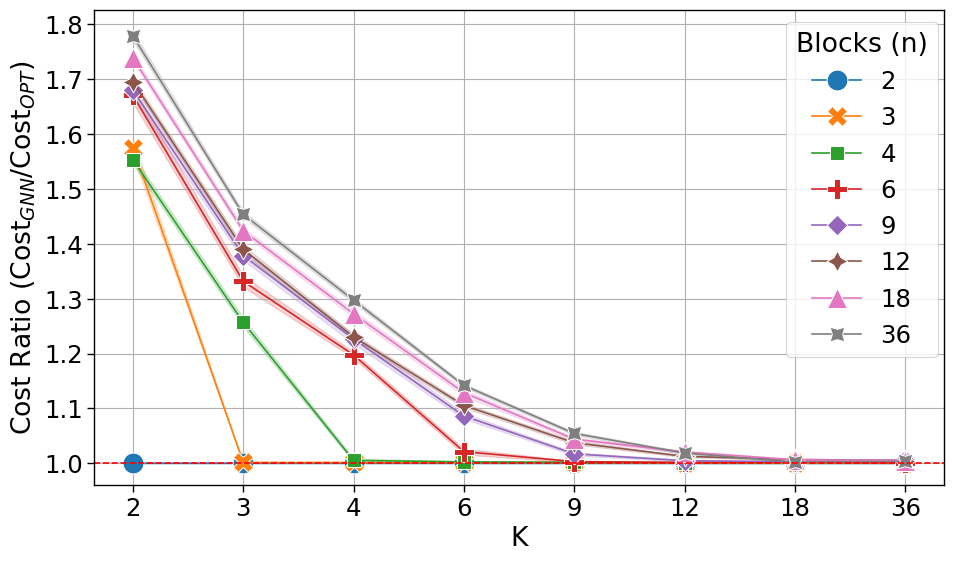

In [ ]:
# plot at varying out_channels (GNN only, compare with its min)
df = pd.read_csv('./results/gnn_vs_gurobi_results_varying_out_channels.csv')
df_gurobi = pd.read_csv('./results/gnn_vs_gurobi_results_fixed_n.csv')
import seaborn as sns
import matplotlib.pyplot as plt

best_out = df_gurobi[['k', 'num_blocks', 'Gurobi']]
df_plot = df.merge(best_out, on=['k', 'num_blocks'], suffixes=('', '_best'))
df_plot['GNN'] = df_plot['GNN'] / df_plot['Gurobi']

fig = plt.figure(figsize=(10,6))

mapto_out_clusters = {v: i for i, v in enumerate(sorted(df_plot['out_clusters'].unique()))}
df_plot['out_clusters_mapped'] = df_plot['out_clusters'].map(mapto_out_clusters)

full_levels = sorted(df['num_blocks'].unique())
sns.lineplot(
    data=df_plot,
    x='out_clusters_mapped',
    y='GNN',
    hue='num_blocks',
    style='num_blocks',
    hue_order=full_levels,
    dashes=False,
    legend='full',
    markers=True,
    markersize=15,
    palette=sns.color_palette("tab10", n_colors=len(full_levels)),
    errorbar='se'
)

plt.legend(title='Blocks (n)', bbox_to_anchor=(0.8, 1), loc='upper left')
plt.axhline(1., color='red', linestyle='--')
plt.xticks(np.arange(len(df_plot['out_clusters'].unique())), sorted(df_plot['out_clusters'].unique()))
plt.xlabel('K')
#plt.xscale('log')
plt.ylabel(r'Cost Ratio ($\text{Cost}_{GNN} / \text{Cost}_{OPT}$)')


plt.grid()
plt.tight_layout()
plt.show()



plt.savefig('./results/figures/gnn_vs_gurobi_varying_out_channels.pdf')

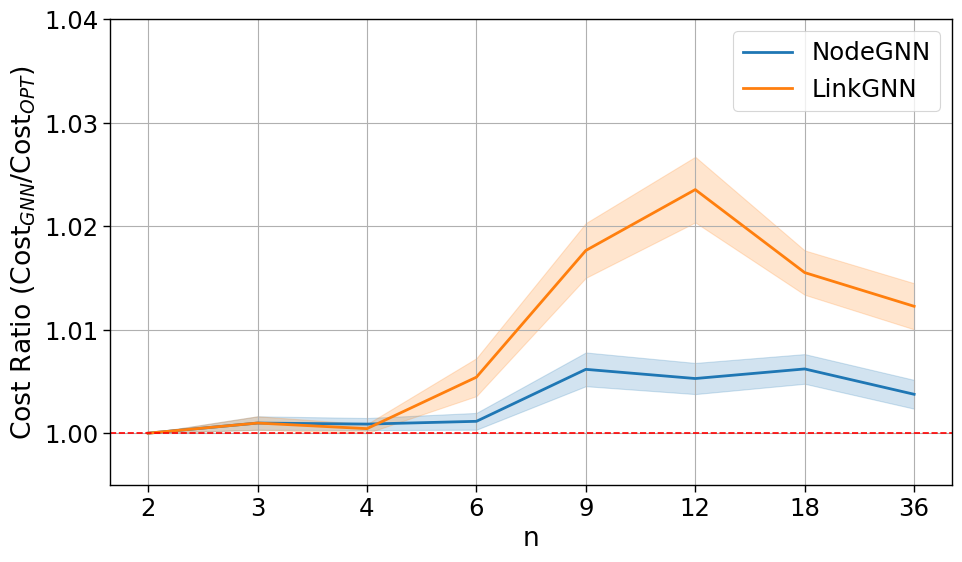

In [ ]:
sns.set_context('paper', font_scale=2)

df = pd.read_csv('./results/gnn_vs_gurobi_results_fixed_n.csv')
# plot difference between gnn and gurobi
# and between linkgnn and gurobi
import matplotlib.pyplot as plt
import seaborn as sns
df['NodeGNN'] =( df['NodeGNN'])/df['Gurobi']
df['NodeGNN (rounded)'] = (df['GNN_converted'])/df['Gurobi']
#df['LinkGNN'] = (df['LinkGNN'])/df['Gurobi']
df['LinkGNN (rounded)'] = (df['LinkGNN_converted'])/df['Gurobi']
df['KwikCluster'] = (df['KwikCluster'])/df['Gurobi']
df['ModPivot'] = (df['ModPivot'])/df['Gurobi']

df_all = df.melt(id_vars=['num_blocks'], value_vars=['NodeGNN', 'NodeGNN (rounded)', 'LinkGNN', 'LinkGNN (rounded)'])
df_all['rounded'] = df_all['variable'].str.contains('rounded')
df_all['variable'] = df_all['variable'].str.replace(' (rounded)', '', regex=False)
df_all.loc[df_all.variable.isin(['KwikCluster', 'ModPivot']), 'rounded'] = True




# keep only rounded versions
df_all = df_all[df_all['rounded'] == True]

mapto_num_blocks = {v: i for i, v in enumerate(sorted(df_all['num_blocks'].unique()))}
df_all['num_blocks_mapped'] = df_all['num_blocks'].map(mapto_num_blocks)
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df_all, x='num_blocks_mapped', y='value',  hue='variable', markers=True, linewidth=2, markersize=15,errorbar='se')
plt.axhline(1., color='red', linestyle='--')
# on the x axis use only the num_blocks values present in the data
plt.xticks(np.arange(len(df['num_blocks'].unique())), sorted(df['num_blocks'].unique()))
plt.xlabel('n')
plt.ylabel(r'Cost Ratio ($\text{Cost}_{GNN} / \text{Cost}_{OPT}$)')
#plt.legend(title='Method Comparison')
# remove 'variable' and 'rounded' from legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = []
new_handles = []
for label in labels:
    if ' (rounded)' in label:
        new_labels.append(label.replace(' (rounded)', ''))
    elif 'rounded' == label or label == 'variable':
        continue
    elif label == 'True':
        new_labels.append('Rounded')
    elif label == 'False':
        new_labels.append('Relaxed')
    else:
        new_labels.append(label)
    new_handles.append(handles[labels.index(label)])

plt.legend(new_handles, new_labels,  loc='best')
plt.ylim(0.995, 1.04)
plt.grid()
plt.tight_layout()
plt.show()
fig.savefig('./results/all_vs_gurobi.pdf')

## Correlation Clustering Benchmark

In [3]:
full_df = load_result('full_results_transductive.csv')

cc_bench_datasets = ['polblogs', 'ca-GrQc', 'ca-HepTh', 'ca-AstroPh', 'email-Enron', 'cond-mat-2005']

['Linear' 'LinearLink' 'LinkEmbOnly' 'NodeGNN' 'KwikCluster' 'CFP'
 'LinkGNN' 'ModifiedPivot']
['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP', NaN]
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_df['cost'] = dataset_df.groupby('name')['cost'].transform(lambda x: x / x.min())


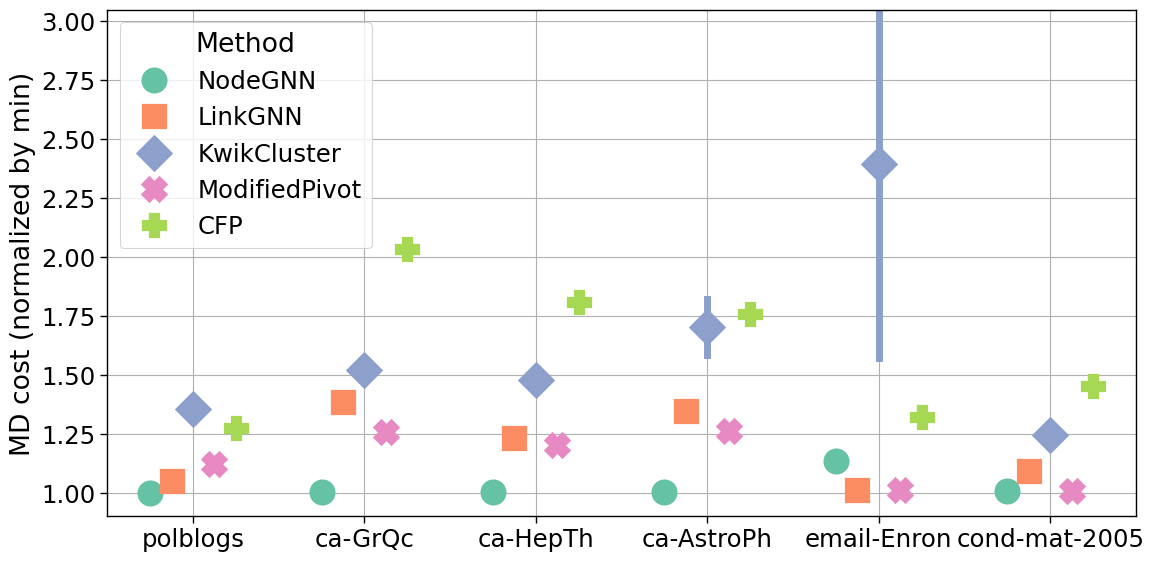

In [4]:
plot_cost_results(full_df, 'cc_bench_datasets', cc_bench_datasets, ylims=(0.9, 3.05), s=15)

In [ ]:
df = clean_df(full_df, cc_bench_datasets)
variables = ['cost',]
agg_df = aggregate_df(df, variables=variables)

# remove metric column
agg_df = agg_df.reset_index().drop(columns=['metric']).set_index('name')

agg_df.to_latex('./results/tables/cc_bench_agg_results.tex')
agg_df

['Linear' 'LinearLink' 'LinkEmbOnly' 'NodeGNN' 'KwikCluster' 'CFP'
 'LinkGNN' 'ModifiedPivot']
['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP', NaN]
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_df[var] = dataset_df.groupby('name')[var].transform(lambda x: x / x.min())
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = dataset_df.groupby(['name', 'method'])[var].agg(agg_func).reset_index()


method,NodeGNN,LinkGNN,KwikCluster,ModifiedPivot,CFP
name,,,,,
polblogs,1.001 ± 3e-04,1.051 ± 0.001,1.358 ± 0.036,1.123 ± 4e-04,1.274 ± 0.002
ca-GrQc,1.005 ± 0.001,1.386 ± 0.004,1.519 ± 0.025,1.259 ± 0.013,2.036 ± 0.005
ca-HepTh,1.003 ± 0.001,1.231 ± 0.002,1.477 ± 0.019,1.205 ± 0.004,1.808 ± 0.002
ca-AstroPh,1.002 ± 7e-04,1.349 ± 7e-04,1.703 ± 0.119,1.263 ± 0.013,1.759 ± 0.002
email-Enron,1.136 ± 0.005,1.012 ± 2e-04,2.396 ± 0.823,1.014 ± 0.004,1.322 ± 8e-04
cond-mat-2005,1.009 ± 0.005,1.094 ± 3e-04,1.247 ± 0.020,1.007 ± 0.003,1.454 ± 7e-04


## Feature datasets

In [6]:
full_df = load_result('full_results_transductive.csv')

feature_datasets = ['Cora', 'PubMed', 'CiteSeer',  'AmazonPhoto', 'AmazonPC', 'GitHub', 'Facebook', 'WikiCS', 'OGBN-Arxiv']

['KwikCluster' 'Linear' 'LinearLink' 'LinkEmbOnly' 'CFP' 'NodeGNN'
 'LinkGNN' 'ModifiedPivot']
['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP', NaN]
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_df['cost'] = dataset_df.groupby('name')['cost'].transform(lambda x: x / x.min())


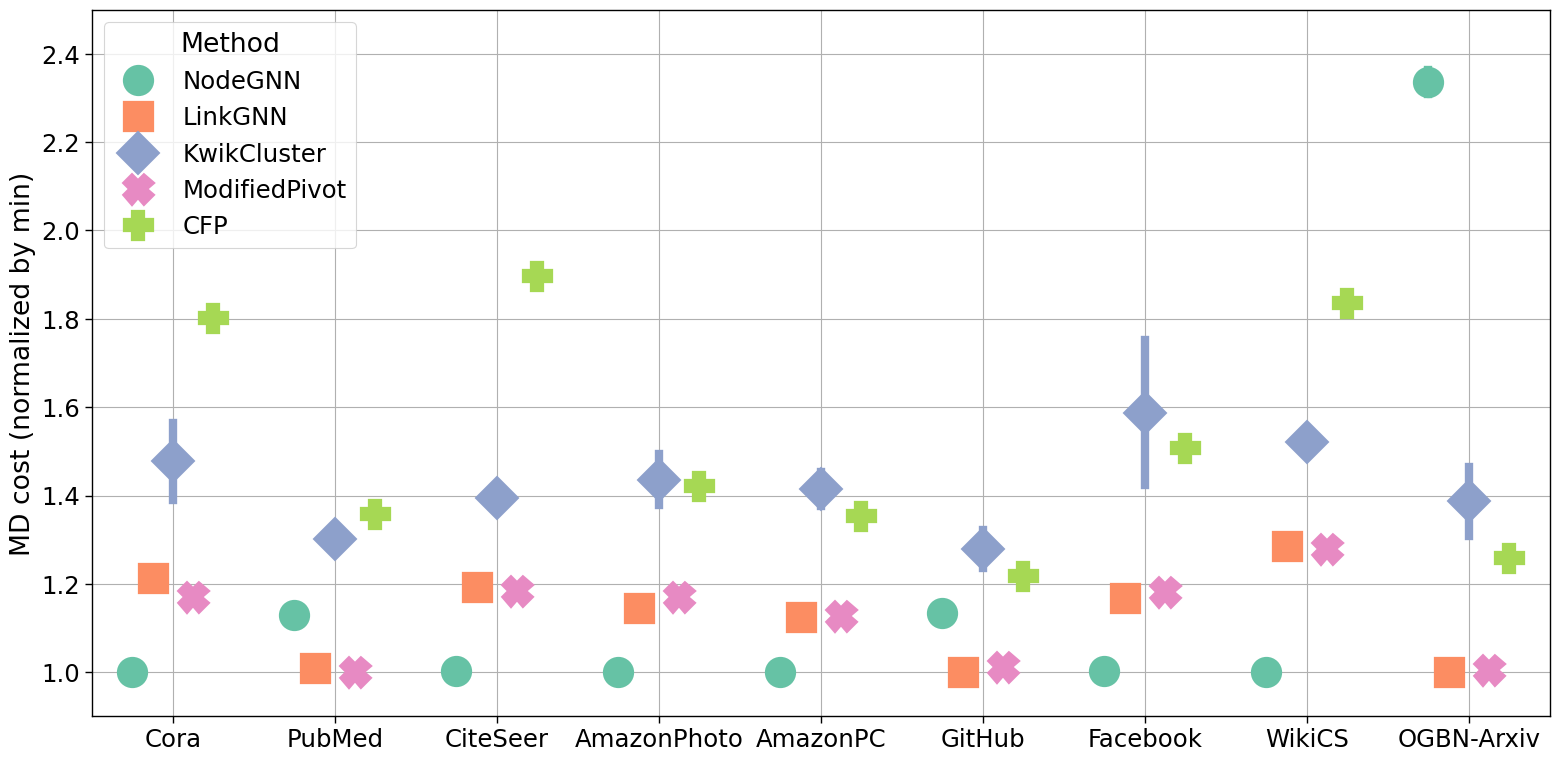

In [7]:
plot_cost_results(full_df, 'feature_datasets', feature_datasets, ylims=(0.9, 2.5), figsize=(16,8), s=18)

In [ ]:
df = clean_df(full_df, feature_datasets)
variables = ['cost',]
agg_df = aggregate_df(df, variables=variables)
# remove metric column
agg_df = agg_df.reset_index().drop(columns=['metric']).set_index('name')

agg_df.to_latex('./results/tables/feature_datasets_agg_results.tex')
agg_df

['KwikCluster' 'Linear' 'LinearLink' 'LinkEmbOnly' 'CFP' 'NodeGNN'
 'LinkGNN' 'ModifiedPivot']
['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP', NaN]
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_df[var] = dataset_df.groupby('name')[var].transform(lambda x: x / x.min())
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = dataset_df.groupby(['name', 'method'])[var].agg(agg_func).reset_index()


method,NodeGNN,LinkGNN,KwikCluster,ModifiedPivot,CFP
name,,,,,
Cora,1.001 ± 7e-04,1.214 ± 0.002,1.477 ± 0.087,1.170 ± 0.009,1.803 ± 0.002
PubMed,1.130 ± 0.003,1.011 ± 6e-04,1.303 ± 0.023,1.001 ± 6e-04,1.358 ± 8e-04
CiteSeer,1.004 ± 0.001,1.194 ± 0.004,1.394 ± 0.007,1.183 ± 0.004,1.897 ± 0.002
AmazonPhoto,1.001 ± 4e-04,1.146 ± 0.002,1.436 ± 0.058,1.170 ± 0.005,1.421 ± 0.002
AmazonPC,1.002 ± 4e-04,1.125 ± 0.001,1.415 ± 0.039,1.128 ± 4e-04,1.353 ± 9e-04
GitHub,1.134 ± 0.016,1.000 ± 4e-05,1.279 ± 0.042,1.012 ± 0.003,1.217 ± 0.001
Facebook,1.003 ± 0.001,1.169 ± 9e-04,1.588 ± 0.164,1.181 ± 0.004,1.508 ± 0.001
WikiCS,1.001 ± 2e-04,1.285 ± 7e-04,1.521 ± 0.026,1.279 ± 0.010,1.836 ± 0.003
OGBN-Arxiv,2.336 ± 0.027,1.001 ± 6e-04,1.387 ± 0.078,1.006 ± 8e-04,1.258 ± 7e-04


['LinkGNN' 'LinearLink' 'NodeGNN' 'Linear' 'KwikCluster' 'ModifiedPivot']
['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)', NaN]
Categories (4, object): ['NodeGNN (I)' < 'LinkGNN (I)' < 'KwikCluster (T)' < 'ModifiedPivot (T)']
     num_nodes  num_edges  name           method  max_clusters  \
9         2708      10556  Cora              NaN           NaN   
116       2708      10556  Cora              NaN        2708.0   
115       2708      10556  Cora              NaN        2708.0   
0         2708      10556  Cora      LinkGNN (I)           NaN   
121       2708      10556  Cora  KwikCluster (T)        2708.0   

               objective    lr  weight_decay random_pivots  in_channels  \
9          LinkObjective  0.01           0.0          1000       1433.0   
116  MatrixFactorization  0.01           0.0          1000       1433.0   
115  MatrixFactorization  0.01           0.0          1000       1433.0   
0          LinkObjective  0.01           0.0          1

/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_df['method'].replace({'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)', 'LinearLink': 'LinkLinear (I)'}, inplace=True)
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

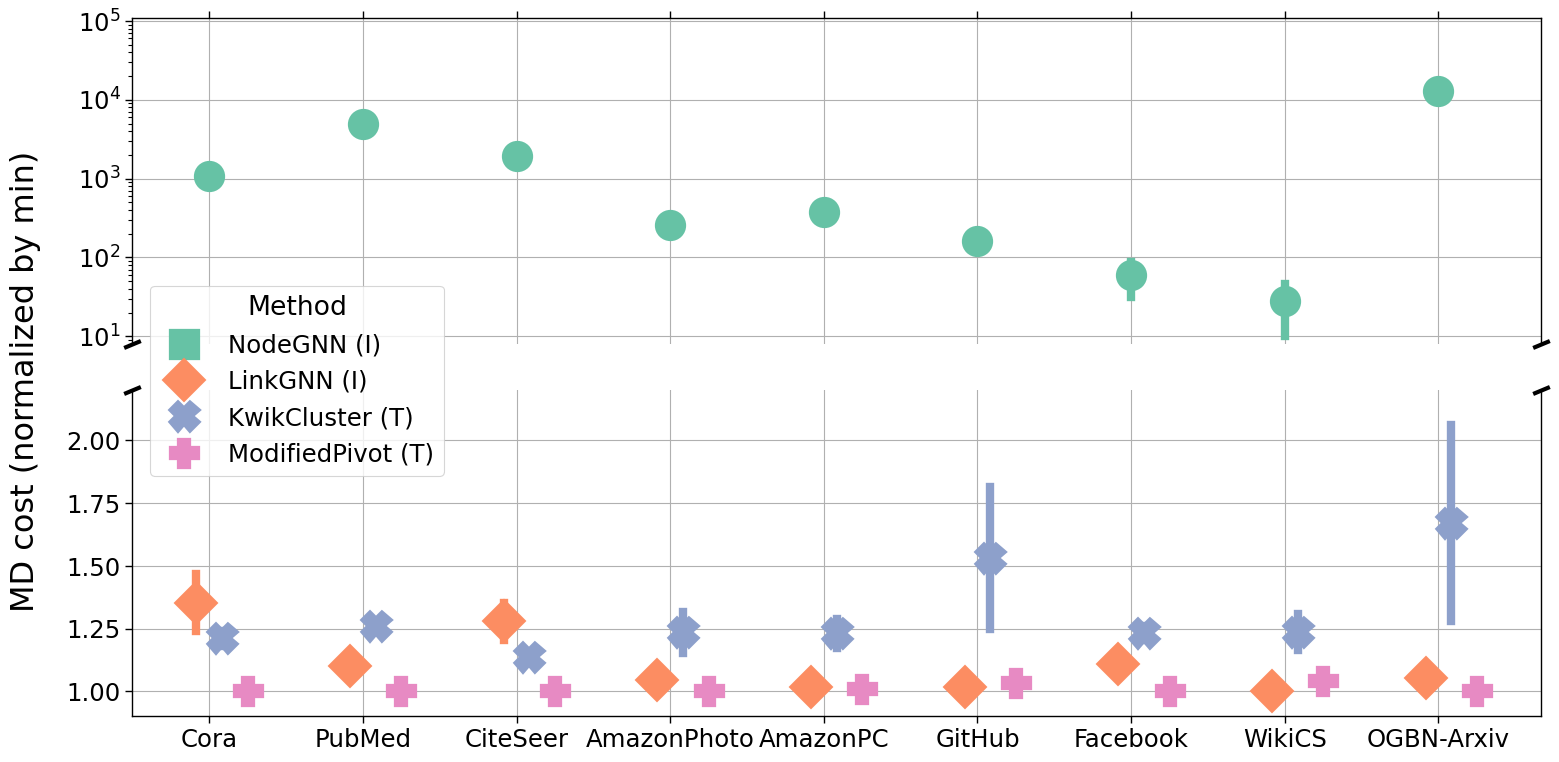

In [9]:
full_df_inductive = load_result('full_results_inductive.csv', inductive=True)

plot_cost_results_inductive(full_df_inductive, 'feature_datasets', feature_datasets, ylims=[(0.9,2.2), (8, 110000)], figsize=(16,8), s=18, logscale=True)
#plot_cost_results(full_df_inductive, 'inductive_feature_datasets', feature_datasets, logscale=True, figsize=(16,8), ylims=(0.8, 1100), s=15, inductive=True)

In [ ]:
# create a table where each row is a dataset, and we have two columns: one is the runtime of KwikCluster, and the other is the inference_time of LinkGNN
df_inductive = clean_df(full_df_inductive, feature_datasets)

agg_func = custom_agg_func(2, 'f')

inductive_runtimes = df_inductive.groupby(['name', 'method'])[["inference_time", "runtime"]].agg(agg_func).reset_index()
inductive_runtimes = inductive_runtimes[inductive_runtimes['method'].isin(['LinkGNN', 'KwikCluster', 'ModifiedPivot'])]

inductive_runtimes['final'] = inductive_runtimes.apply(lambda row: row['inference_time'] if row['method'] == 'LinkGNN' else row['runtime'], axis=1)
inductive_runtimes = inductive_runtimes[['name', 'method', 'final']]


inductive_runtimes = inductive_runtimes.pivot(index='name', columns='method')
inductive_runtimes.columns = inductive_runtimes.columns.droplevel(0)

#inductive_runtimes = inductive_runtimes.reset_index()
inductive_runtimes.to_latex('./results/tables/inductive_runtimes.tex')
inductive_runtimes

['LinkGNN' 'LinearLink' 'NodeGNN' 'Linear' 'KwikCluster' 'ModifiedPivot']
['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', NaN]
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3147447545.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inductive_runtimes = df_inductive.groupby(['name', 'method'])[["inference_time", "runtime"]].agg(agg_func).reset_index()


method,LinkGNN,KwikCluster,ModifiedPivot
name,,,
Cora,0.01 ± 3e-04,0.01 ± 2e-04,1.77 ± 0.16
PubMed,0.01 ± 4e-04,0.57 ± 0.08,193.40 ± 2.60
CiteSeer,0.02 ± 2e-03,0.02 ± 1e-04,1.00 ± 0.07
AmazonPhoto,0.01 ± 2e-04,0.03 ± 1e-04,36.60 ± 1.96
AmazonPC,0.02 ± 2e-03,0.16 ± 4e-03,146.33 ± 3.06
GitHub,0.02 ± 2e-03,2.23 ± 0.08,1377.66 ± 72.75
Facebook,0.01 ± 3e-04,0.51 ± 0.08,300.46 ± 5.29
WikiCS,0.01 ± 1e-03,0.16 ± 2e-03,121.32 ± 5.32
OGBN-Arxiv,0.04 ± 7e-04,30.88 ± 0.31,25061.42 ± 2421.08


In [ ]:
df_inductive = clean_df(full_df_inductive, feature_datasets, inductive=True)
#print(df_inductive['method'].unique())
# only use 'NodeGNN', 'LinkGNN', 'KwikCluster'
#df_inductive = df_inductive[df_inductive['method'].isin(['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)', 'LinkLinear (I)'])]

variables = ['cost',]
agg_df = aggregate_df(df_inductive, variables=variables)
agg_df.dropna(inplace=True, axis=1)
# rename methods to 'NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)'
#agg_df = agg_df.rename(columns={'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)'})
# remove metric from indexn
agg_df = agg_df.reset_index(level='metric', drop=True)
agg_df.to_latex('./results/tables/inductive_feature_datasets_agg_results.tex')
agg_df

['LinkGNN' 'LinearLink' 'NodeGNN' 'Linear' 'KwikCluster' 'ModifiedPivot']
['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)', NaN]
Categories (4, object): ['NodeGNN (I)' < 'LinkGNN (I)' < 'KwikCluster (T)' < 'ModifiedPivot (T)']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_df['method'].replace({'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)', 'LinearLink': 'LinkLinear (I)'}, inplace=True)
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

method,NodeGNN (I),LinkGNN (I),KwikCluster (T),ModifiedPivot (T)
name,,,,
Cora,1188.193 ± 0.874,1.481 ± 0.136,1.322 ± 0.049,1.092 ± 0.032
PubMed,5087.865 ± 0.013,1.136 ± 0.012,1.299 ± 0.021,1.032 ± 0.015
CiteSeer,2121.325 ± 0.036,1.406 ± 0.036,1.259 ± 0.054,1.112 ± 0.058
AmazonPhoto,265.362 ± 0.018,1.082 ± 0.014,1.277 ± 0.080,1.037 ± 0.015
AmazonPC,383.042 ± 0.012,1.036 ± 0.011,1.257 ± 0.061,1.030 ± 0.011
GitHub,174.831 ± 27.742,1.095 ± 0.030,1.647 ± 0.307,1.112 ± 0.033
Facebook,62.721 ± 29.124,1.181 ± 0.011,1.317 ± 0.054,1.066 ± 0.022
WikiCS,28.395 ± 17.692,1.070 ± 0.030,1.314 ± 0.063,1.111 ± 0.027
OGBN-Arxiv,13170.669 ± 42.923,1.072 ± 0.014,1.696 ± 0.391,1.021 ± 0.009


# Ablation study

In [12]:

df = load_result('full_results_ablation.csv')


df.conv_type.fillna('No Conv.', inplace=True)
df.num_layers.fillna(0, inplace=True)

df['method'] = df.method.replace({'GNNModel': 'NodeGNN', 'LinkGNNModel': 'LinkGNN'})
df.method.unique()

df['cost'] = df.groupby('name')['cost'].transform(lambda x: x / x.min())


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/2649868574.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.conv_type.fillna('No Conv.', inplace=True)
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/2649868574.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

## GNN only

### Layer comparison

In [ ]:
curr_df = df[ ~df['method'].str.contains('Link')] 
curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axis=1)

curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

curr_df = curr_df[curr_df.conv_type.isin(['GCN', 'No Conv.'])]

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'method'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'EMBOnly', 'Linear', '1 Layer', '2 Layers', '3 Layers']
agg_df['method'] = pd.Categorical(agg_df['method'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','method'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='method', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)



print(agg_df)
agg_df.to_latex('./results/tables/ablation_node_layers.tex')

/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/2988411301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axis=1)


method              EMBOnly        Linear       1 Layer      2 Layers  \
name                                                                    
ca-AstroPh     1.65 ± 6e-03  1.64 ± 2e-04  1.00 ± 1e-03   2.16 ± 0.04   
ca-GrQc         2.36 ± 0.24  2.35 ± 2e-03  1.00 ± 6e-04  90.00 ± 9.79   
ca-HepTh        1.74 ± 0.02  1.64 ± 1e-03  1.00 ± 9e-04   3.66 ± 0.18   
cond-mat-2005   1.80 ± 0.01  1.88 ± 1e-03  1.01 ± 5e-03   4.06 ± 0.31   
email-Enron    1.50 ± 2e-03  1.56 ± 2e-03  1.12 ± 5e-03   5.71 ± 2.80   
polblogs        1.06 ± 0.03  1.11 ± 5e-04  1.00 ± 2e-04   3.75 ± 2.38   

method                3 Layers  
name                            
ca-AstroPh     1371.64 ± 0e+00  
ca-GrQc        2224.25 ± 0e+00  
ca-HepTh       2965.73 ± 0e+00  
cond-mat-2005  5643.22 ± 0e+00  
email-Enron    4003.65 ± 0e+00  
polblogs          25.89 ± 4.63  


### Conv comparison

In [ ]:
curr_df = df[ ~df['method'].str.contains('Link')]
curr_df = curr_df[curr_df['conv_type']!= 'No Conv.']
curr_df = curr_df[curr_df['num_layers']==1]
curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'conv_type'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'GCN', 'GraphSAGE', 'GIN', 'GAT']
agg_df['conv_type'] = pd.Categorical(agg_df['conv_type'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','conv_type'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='conv_type', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)

print(agg_df)

agg_df.to_latex('./results/tables/ablation_node_conv.tex')


conv_type               GCN     GraphSAGE               GIN          GAT
name                                                                    
ca-AstroPh     1.00 ± 1e-03  1.08 ± 9e-04      42.88 ± 7.06  2.26 ± 0.10
ca-GrQc        1.00 ± 6e-04  1.30 ± 4e-03      30.00 ± 2.99  2.18 ± 0.08
ca-HepTh       1.00 ± 9e-04  1.25 ± 1e-03      55.47 ± 8.22  2.18 ± 0.05
cond-mat-2005  1.01 ± 5e-03  1.33 ± 5e-03  3350.27 ± 583.15  3.01 ± 0.09
email-Enron    1.12 ± 5e-03   7.07 ± 0.87  1056.88 ± 351.45  6.26 ± 0.58
polblogs       1.00 ± 2e-04  1.05 ± 1e-03       1.39 ± 0.05  1.68 ± 0.10


## Link Only

### Layer comparison

In [ ]:
curr_df = df[ df['method'].str.contains('Link')] 
curr_df['method'] = curr_df['method'].replace({'LinkEmbOnly': 'EMBOnly', 'LinearLink': 'Linear'})
curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axis=1)

curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

curr_df = curr_df[curr_df.conv_type.isin(['GCN', 'No Conv.'])]

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'method'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'EMBOnly', 'Linear', '1 Layer', '2 Layers', '3 Layers']
agg_df['method'] = pd.Categorical(agg_df['method'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','method'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='method', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)




print(agg_df)
agg_df.to_latex('./results/tables/ablation_link_layers.tex')


method              EMBOnly        Linear       1 Layer      2 Layers  \
name                                                                    
ca-AstroPh     1.29 ± 4e-03  1.54 ± 0e+00  1.38 ± 2e-04  1.40 ± 5e-03   
ca-GrQc         1.33 ± 0.03  1.98 ± 3e-03  1.32 ± 1e-03   1.43 ± 0.01   
ca-HepTh        1.40 ± 0.02  1.58 ± 0e+00  1.23 ± 3e-04  1.29 ± 1e-03   
cond-mat-2005  1.23 ± 1e-03  1.27 ± 0e+00  1.05 ± 2e-03  1.11 ± 3e-03   
email-Enron    1.09 ± 1e-04  1.09 ± 1e-06  1.00 ± 2e-04  1.04 ± 4e-04   
polblogs       1.05 ± 1e-05  1.06 ± 8e-04  1.04 ± 7e-04  1.07 ± 3e-03   

method             3 Layers  
name                         
ca-AstroPh     1.37 ± 9e-03  
ca-GrQc         1.46 ± 0.02  
ca-HepTh       1.30 ± 6e-03  
cond-mat-2005   1.12 ± 0.01  
email-Enron     1.14 ± 0.03  
polblogs        1.13 ± 0.01  


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3136394740.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df['method'] = curr_df['method'].replace({'LinkEmbOnly': 'EMBOnly', 'LinearLink': 'Linear'})
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3136394740.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axi

### Conv comparison

In [ ]:
curr_df = df[ df['method'].str.contains('Link')]
curr_df = curr_df[curr_df['conv_type']!= 'No Conv.']
curr_df = curr_df[curr_df['num_layers']==1]

curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'conv_type'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'GCN', 'GraphSAGE', 'GIN', 'GAT']
agg_df['conv_type'] = pd.Categorical(agg_df['conv_type'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','conv_type'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='conv_type', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)

print(agg_df)

agg_df.to_latex('./results/tables/ablation_link_conv.tex')


conv_type               GCN     GraphSAGE           GIN           GAT
name                                                                 
ca-AstroPh     1.38 ± 2e-04  1.36 ± 2e-04  1.37 ± 2e-03  1.34 ± 9e-03
ca-GrQc        1.32 ± 1e-03  1.37 ± 4e-03   1.50 ± 0.03  1.31 ± 9e-03
ca-HepTh       1.23 ± 3e-04  1.28 ± 7e-03   1.36 ± 0.01  1.24 ± 3e-03
cond-mat-2005  1.05 ± 2e-03  1.11 ± 5e-03  1.19 ± 4e-03  1.04 ± 1e-03
email-Enron    1.00 ± 2e-04   5.99 ± 0.50   1.12 ± 0.02   1.08 ± 0.01
polblogs       1.04 ± 7e-04  1.06 ± 1e-03  1.06 ± 2e-03  1.08 ± 8e-03
